In [1]:
#Load Libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

Current working directory:
/home/yvonne_chook/github/207-Summer26-FinalProject-MLModel/Data_Preprocessing/SFO_NOAA_Preprocessing_Yvonne


In [3]:
#Load data
NOAA_SFO_df = pd.read_parquet(
    "../../Data_Extraction/SFO_NOAA_raw_YvonneChook/NOAA_SFO_2022_2026.parquet"
)

NOAA_SFO_df.head()

,STATION,Station_name,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,...,precipitation_24_hour_Quality_Code,precipitation_24_hour_Report_Type,precipitation_24_hour_Source_Code,precipitation_24_hour_Source_Station_ID,REM,REM_Measurement_Code,REM_Quality_Code,REM_Report_Type,REM_Source_Code,REM_Source_Station_ID
0,USW00023234,SAN FRANCISCO INTL AP,2024-01-01T00:00:00,2024,01,01,00,00,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,SYN08072494 32666 80204 10133 20100 30154 4018...,NaN,NaN,FM12,223,ICAO-KSFO
1,USW00023234,SAN FRANCISCO INTL AP,2024-01-01T00:56:00,2024,01,01,00,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET083METAR KSFO 010056Z 01004KT 10SM FEW040 B...,NaN,NaN,FM15,223,ICAO-KSFO
2,USW00023234,SAN FRANCISCO INTL AP,2024-01-01T01:56:00,2024,01,01,01,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET083METAR KSFO 010156Z 00000KT 10SM FEW040 B...,NaN,NaN,FM15,223,ICAO-KSFO
3,USW00023234,SAN FRANCISCO INTL AP,2024-01-01T02:56:00,2024,01,01,02,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET096METAR KSFO 010256Z 00000KT 10SM FEW020 S...,NaN,NaN,FM15,223,ICAO-KSFO
4,USW00023234,SAN FRANCISCO INTL AP,2024-01-01T03:00:00,2024,01,01,03,00,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,SYN06472494 32566 60000 10128 20094 30158 4018...,NaN,NaN,FM12,223,ICAO-KSFO


**Review Data available**

In [4]:
#Check shape 
print("NOAA Extract Shape:")
print(NOAA_SFO_df.shape)

NOAA Extract Shape:
(89176, 329)


In [5]:
# Review NOAA SFO dataset info
NOAA_summary = pd.DataFrame({
    "column_name": NOAA_SFO_df.columns,
    "dtype": NOAA_SFO_df.dtypes.values,
    "nulls_count": NOAA_SFO_df.isna().sum().values,
    "nulls_percent": (NOAA_SFO_df.isna().mean().values * 100).round(3),
    "unique_values": NOAA_SFO_df.nunique().values
})

#I want to see all data
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


display(NOAA_summary)

,column_name,dtype,nulls_count,nulls_percent,unique_values
0,STATION,str,0,0.000,1
1,Station_name,str,0,0.000,1
2,DATE,str,0,0.000,89176
3,Year,str,0,0.000,5
4,Month,str,0,0.000,12
5,Day,str,0,0.000,31
6,Hour,str,0,0.000,24
7,Minute,str,0,0.000,60
8,LATITUDE,str,0,0.000,1
9,LONGITUDE,str,0,0.000,1


**Clean Data Type**

In [6]:
#Convert DATE column to datatime

NOAA_SFO_cleaned = NOAA_SFO_df

NOAA_SFO_cleaned["DATE"] = pd.to_datetime(NOAA_SFO_cleaned["DATE"])

#check
NOAA_SFO_cleaned["DATE"].dtype


dtype('<M8[us]')

In [7]:
# convert any date time components to ints

#specify columns and intended datatype
date_str_to_ints = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Minute"
]

for col in date_str_to_ints:
    NOAA_SFO_cleaned[col] = pd.to_numeric(NOAA_SFO_cleaned[col])



In [8]:
# convert any location features into floats
location_str_to_floats = [
    "LATITUDE", 
    "LONGITUDE", 
    "ELEVATION"
]

for col in location_str_to_floats:
    NOAA_SFO_cleaned[col] = pd.to_numeric(NOAA_SFO_cleaned[col])

In [9]:
#any weather measurement to numeric value
numeric_weather_cols = [
    "temperature",
    "dew_point_temperature",
    "station_level_pressure",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "wind_gust",
    "precipitation",
    "relative_humidity",
    "wet_bulb_temperature",
    "snow_depth",
    "visibility",
    "altimeter",
    "pressure_3hr_change",
    "sky_condition_baseht",
    "ceiling_height",
    "sky_cover_layer_1",
    "sky_cover_layer_2",
    "sky_cover_layer_3",
    "sky_cover_layer_4",
    "sky_cover_layer_baseht_1",
    "sky_cover_layer_baseht_2",
    "sky_cover_layer_baseht_3",
    "sky_cover_layer_baseht_4",
    "sky_cover_summation_baseht_1",
    "sky_cover_summation_baseht_2",
    "sky_cover_summation_baseht_3",
    "sky_cover_summation_baseht_4",
    "precipitation_5_minute",
    "precipitation_15_minute",
    "precipitation_3_hour",
    "precipitation_6_hour",
    "precipitation_9_hour",
    "precipitation_12_hour",
    "precipitation_15_hour",
    "precipitation_18_hour",
    "precipitation_21_hour",
    "precipitation_24_hour"
]

for col in numeric_weather_cols:
    if col in NOAA_SFO_cleaned.columns:
        NOAA_SFO_cleaned[col] = pd.to_numeric(NOAA_SFO_cleaned[col])

**Note Distribution of data across the years are not the same**

Before

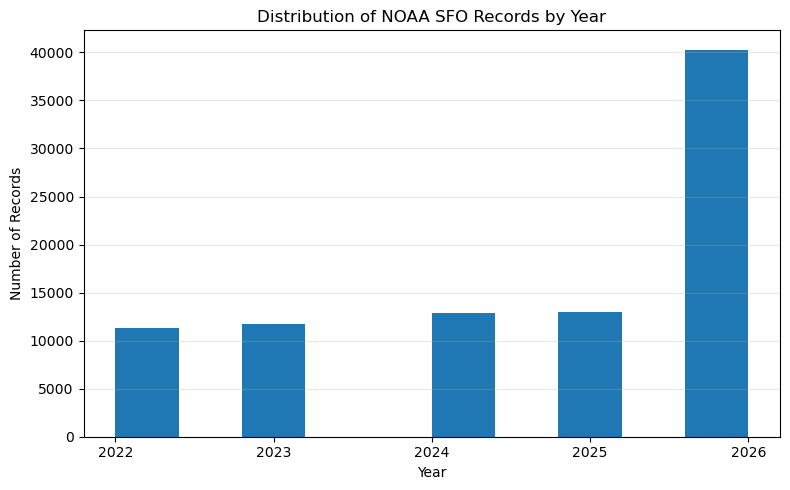

In [10]:
#Distribution of data before

plt.figure(figsize=(8, 5))

plt.hist(NOAA_SFO_cleaned["Year"])

plt.title("Distribution of NOAA SFO Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(sorted(NOAA_SFO_cleaned["Year"].unique()))  # removes 2022.5, 2023.5, etc.

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [11]:
# filter for unique entries only
NOAA_SFO_cleaned = NOAA_SFO_cleaned.drop_duplicates()

#fiter cases where columns are entirely null
NOAA_SFO_cleaned = NOAA_SFO_cleaned.dropna(axis=1, how="all")

#drop where temp is null
NOAA_SFO_cleaned = NOAA_SFO_cleaned.dropna(subset=["temperature"])


#Check shape
print(NOAA_SFO_cleaned.shape)

(53785, 220)


After

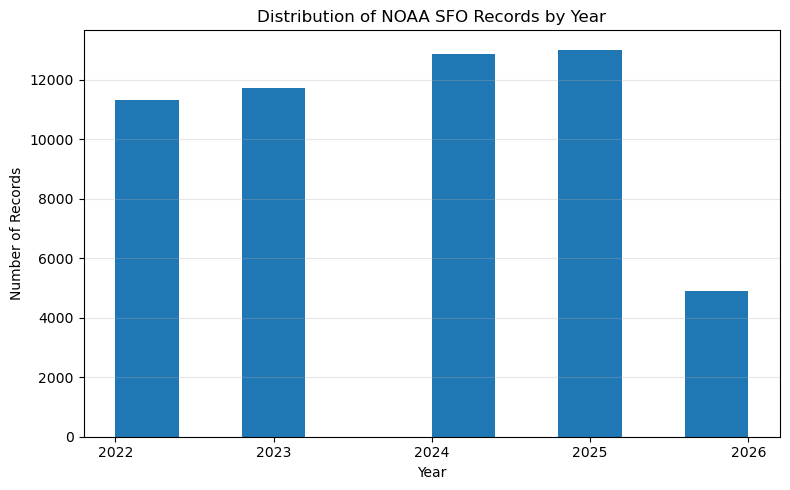

In [12]:
#Distribution of data after - this will help us in EDA data split later

plt.figure(figsize=(8, 5))

plt.hist(NOAA_SFO_cleaned["Year"])

plt.title("Distribution of NOAA SFO Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(sorted(NOAA_SFO_cleaned["Year"].unique()))  # removes 2022.5, 2023.5, etc.

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

**Comment:** No change in shape, indicating all entries have unique data combinations

In [13]:
#review final version with dtype cleaning

# Review NOAA SFO dataset info
NOAA_summary = pd.DataFrame({
    "column_name": NOAA_SFO_df.columns,
    "dtype": NOAA_SFO_df.dtypes.values,
    "nulls_count": NOAA_SFO_df.isna().sum().values,
    "nulls_percent": (NOAA_SFO_df.isna().mean().values * 100).round(3),
    "unique_values": NOAA_SFO_df.nunique().values
})

#I want to see all data
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# filter for unique entries only
NOAA_SFO_cleaned = NOAA_SFO_cleaned.drop_duplicates()

#fiter cases where columns are entirely null
NOAA_SFO_cleaned = NOAA_SFO_cleaned.dropna(axis=1, how="all")

#drop where temp is null
NOAA_SFO_cleaned = NOAA_SFO_cleaned.dropna(subset=["temperature"])


#Check shape
print(NOAA_SFO_cleaned.shape)


NOAA_summary_cleaned = pd.DataFrame({
    "column_name": NOAA_SFO_cleaned.columns,
    "dtype": NOAA_SFO_cleaned.dtypes.values,
    "nulls_count": NOAA_SFO_cleaned.isna().sum().values,
    "nulls_percent": (NOAA_SFO_cleaned.isna().mean().values * 100).round(3),
    "unique_values": NOAA_SFO_cleaned.nunique().values
})

display(NOAA_summary_cleaned)

NOAA_summary_cleaned

(53785, 220)


,column_name,dtype,nulls_count,nulls_percent,unique_values
0,STATION,str,0,0.000,1
1,Station_name,str,0,0.000,1
2,DATE,datetime64[us],0,0.000,53785
3,Year,int64,0,0.000,5
4,Month,int64,0,0.000,12
5,Day,int64,0,0.000,31
6,Hour,int64,0,0.000,24
7,Minute,int64,0,0.000,60
8,LATITUDE,float64,0,0.000,1
9,LONGITUDE,float64,0,0.000,1


,column_name,dtype,nulls_count,nulls_percent,unique_values
0,STATION,str,0,0.000,1
1,Station_name,str,0,0.000,1
2,DATE,datetime64[us],0,0.000,53785
3,Year,int64,0,0.000,5
4,Month,int64,0,0.000,12
5,Day,int64,0,0.000,31
6,Hour,int64,0,0.000,24
7,Minute,int64,0,0.000,60
8,LATITUDE,float64,0,0.000,1
9,LONGITUDE,float64,0,0.000,1


**Summarized for report**

In [14]:
NOAA_summary_cleaned = pd.DataFrame({
    "column_name": NOAA_SFO_cleaned.columns,
    "dtype": NOAA_SFO_cleaned.dtypes.values,
    "nulls_count": NOAA_SFO_cleaned.isna().sum().values,
    "nulls_percent": (NOAA_SFO_cleaned.isna().mean().values * 100).round(3),
    "unique_values": NOAA_SFO_cleaned.nunique().values
})

display(NOAA_summary_cleaned)

NOAA_summary_cleaned

,column_name,dtype,nulls_count,nulls_percent,unique_values
0,STATION,str,0,0.000,1
1,Station_name,str,0,0.000,1
2,DATE,datetime64[us],0,0.000,53785
3,Year,int64,0,0.000,5
4,Month,int64,0,0.000,12
5,Day,int64,0,0.000,31
6,Hour,int64,0,0.000,24
7,Minute,int64,0,0.000,60
8,LATITUDE,float64,0,0.000,1
9,LONGITUDE,float64,0,0.000,1


,column_name,dtype,nulls_count,nulls_percent,unique_values
0,STATION,str,0,0.000,1
1,Station_name,str,0,0.000,1
2,DATE,datetime64[us],0,0.000,53785
3,Year,int64,0,0.000,5
4,Month,int64,0,0.000,12
5,Day,int64,0,0.000,31
6,Hour,int64,0,0.000,24
7,Minute,int64,0,0.000,60
8,LATITUDE,float64,0,0.000,1
9,LONGITUDE,float64,0,0.000,1


**Sort Data**

In [15]:
#sort data from ascending order
NOAA_SFO_cleaned = NOAA_SFO_cleaned.sort_values(
    by="DATE",
    ascending=True
).reset_index(drop=True)

#Check
NOAA_SFO_cleaned[["DATE", "Year", "Month", "Day", "Hour", "Minute"]].head()

,DATE,Year,Month,Day,Hour,Minute
0,2022-01-01 00:00:00,2022,1,1,0,0
1,2022-01-01 00:56:00,2022,1,1,0,56
2,2022-01-01 01:56:00,2022,1,1,1,56
3,2022-01-01 02:56:00,2022,1,1,2,56
4,2022-01-01 03:56:00,2022,1,1,3,56


In [16]:
# Select features of interest
columns_of_interest = [
    "DATE",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Minute",
    "LATITUDE",
    "LONGITUDE",
    "ELEVATION",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation"
]

NOAA_SFO_cleaned = NOAA_SFO_cleaned[columns_of_interest].copy()

#Check
print(f"NOAA new shape: {NOAA_SFO_cleaned.shape}")
NOAA_SFO_cleaned.head()

NOAA new shape: (53785, 23)


,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,dew_point_temperature,relative_humidity,visibility,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,3.0,11.7,4.4,61.0,16.000,7.7,290.0,1012.4,1009.4,8.2,22000.0,NaN,800.0,NaN,NaN
1,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,5.0,69.0,16.093,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
2,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,4.4,68.0,16.093,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
3,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,4.4,71.0,16.093,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
4,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,5.0,74.0,16.093,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0


**Save Data**

In [18]:
#NOAA_SFO_cleaned.to_parquet("data/NOAA_SFO_2022_2026_cleaned.parquet")